In [19]:
import json
from typing import TypedDict, Annotated, Literal
import operator
from pydantic import BaseModel, Field
from langchain_groq import  ChatGroq 

from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

In [20]:
# 1. DETERMINISTIC MATH / CIRCUIT BREAKER
# ==========================================
def factorial(n: int) -> int:
    result = 1
    for i in range(2, n + 1): result *= i
    return result

def combinations(n: int, k: int) -> int:
    if k < 0 or k > n: return 0
    return factorial(n) // (factorial(k) * factorial(n - k))

def binomial_probability(n: int, k: int, p: float) -> float:
    return combinations(n, k) * (p ** k) * ((1 - p) ** (n - k))

# ==========================================
# 2. STATE AND DATA MODELS
# ==========================================
class AgentDecision(BaseModel):
    intervention: str = Field(description="Recommended medical intervention")
    risk_level: str = Field(description="HIGH, MEDIUM, LOW")
    extracted_anomalies: int

class ClinicalState(TypedDict):
    patient_data: str
    decision: AgentDecision
    audit_passed: bool
    audit_reason: str
    human_feedback: str

In [21]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    # groq_api_key="your-api-key" # Optional if GROQ_API_KEY environment variable is set
)

In [22]:
# 3. GRAPH NODES
# ==========================================
def clinical_reasoner(state: ClinicalState):
    """The primary agent making the initial diagnosis."""
    print("--- REASONING NODE ---")
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an ICU AI. Review telemetry and output a diagnosis."),
        ("human", "Data: {data}")
    ])
    chain = prompt | llm.with_structured_output(AgentDecision)
    decision = chain.invoke({"data": state["patient_data"]})
    return {"decision": decision}

def neuro_symbolic_auditor(state: ClinicalState):
    """The deterministic math gate. If it fails, it trips the circuit breaker."""
    print("--- SYMBOLIC AUDIT NODE ---")
    data = json.loads(state["patient_data"])
    decision = state["decision"]
    
    # Calculate true statistical risk
    actual_prob = binomial_probability(
        n=data["observation_minutes"], 
        k=decision.extracted_anomalies, 
        p=data["baseline_risk"]
    )
    
    # Rigid Thresholding (Circuit Breaker Logic)
    if decision.extracted_anomalies >= 8 and decision.risk_level != "HIGH":
        return {
            "audit_passed": False,
            "audit_reason": f"CRITICAL: Agent assigned {decision.risk_level} risk, but mathematical probability of {decision.extracted_anomalies} anomalies requires HIGH intervention."
        }
    
    return {
        "audit_passed": True,
        "audit_reason": "Mathematical validation passed."
    }

def human_approval_gate(state: ClinicalState):
    """
    ABSOLUTE HITL INTERRUPT: The graph STOPS here every single time.
    It waits indefinitely for the clinician in LangGraph Studio.
    """
    print("--- WAITING FOR HUMAN APPROVAL ---")
    
    # LangGraph Studio intercepts this and waits for human input
    human_response = interrupt({
        "status": "Awaiting Doctor Approval",
        "agent_recommendation": state["decision"].model_dump(),
        "audit_verification": state["audit_reason"],
        "instructions": "Please type 'Approve', 'Reject', or provide manual edits to resume."
    })
    
    return {"human_feedback": str(human_response)}

def execute_clinical_action(state: ClinicalState):
    """Final stage: Only runs AFTER the human resumes the graph."""
    print(f"--- EXECUTING ACTION ---")
    print(f"Doctor's Feedback: {state['human_feedback']}")
    print(f"Executing Intervention: {state['decision'].intervention}")
    return state

In [23]:

# ==========================================
# 4. CONDITIONAL ROUTING
# ==========================================
def check_audit_status(state: ClinicalState) -> Literal["execute_clinical_action", "human_approval_gate"]:
    """Routes based on the deterministic auditor's output."""
    if state["audit_passed"]:
        print("--- ROUTER: AUDIT PASSED -> EXECUTING ---")
        return "execute_clinical_action"
    else:
        print("--- ROUTER: AUDIT FAILED -> ESCALATING TO HUMAN ---")
        return "human_approval_gate"

In [24]:
# ==========================================
# 5. BUILD GRAPH WITH CHECKPOINTER
# ==========================================
workflow = StateGraph(ClinicalState)

workflow.add_node("reasoner", clinical_reasoner)
workflow.add_node("auditor", neuro_symbolic_auditor)
workflow.add_node("human_approval_gate", human_approval_gate)
workflow.add_node("execute_clinical_action", execute_clinical_action)

workflow.add_edge(START, "reasoner")
workflow.add_edge("reasoner", "auditor")

# Conditional edge acts as the logic gate
workflow.add_conditional_edges(
    "auditor",
    check_audit_status
)

# After human review, we proceed to execute (or you could route back to the reasoner for an adaptive loop)
workflow.add_edge("human_approval_gate", "execute_clinical_action")
workflow.add_edge("execute_clinical_action", END)

# MemorySaver is required for HITL and Time-Travel
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

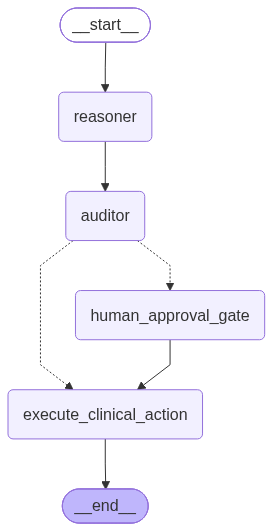

In [25]:
from IPython.display import  Image ,display

display(Image(app.get_graph().draw_mermaid_png()))






In [26]:
config = {"configurable": {"thread_id": "patient_9942"}}
patient_payload = '{"observation_minutes": 60, "baseline_risk": 0.05, "anomalies": 9}'

# 1. Start the run
app.invoke({"patient_data": patient_payload}, config)

--- REASONING NODE ---
--- SYMBOLIC AUDIT NODE ---
--- ROUTER: AUDIT PASSED -> EXECUTING ---
--- EXECUTING ACTION ---


KeyError: 'human_feedback'

In [ ]:
# 2. Clinician reviews and sends the resume command
app.invoke(
    Command(resume={"action": "OVERRIDE: Approved by Dr. Smith"}), 
    config
)

Deserializing unregistered type __main__.AgentDecision from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'AgentDecision')]


{'patient_data': '{"observation_minutes": 60, "baseline_risk": 0.05, "anomalies": 9}',
 'decision': AgentDecision(intervention='Immediate clinical assessment, initiate advanced hemodynamic monitoring, and consider escalation to ICU-level care.', risk_level='HIGH', extracted_anomalies=9),
 'audit_passed': True,
 'audit_reason': 'Mathematical validation passed.'}